In [31]:
import torch
import torchvision
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import copy

In [32]:
device = torch.device("cpu")

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)

In [33]:
BASE_DIR = Path.cwd().parent.parent
TRAIN_DIR = Path(BASE_DIR/'data', 'images', 'train')
VAL_DIR = Path(BASE_DIR/'data', 'images', 'val')
TEST_DIR = Path(BASE_DIR/'data', 'images', 'test')

SPLIT_CSV_PATH = Path(BASE_DIR/'data', 'split.csv')

df = pd.read_csv(SPLIT_CSV_PATH)
df



,filepath,category,defect_type,split
0,test/good/000.png,OK,good,train
1,test/good/001.png,OK,good,train
2,test/good/002.png,OK,good,train
3,test/good/003.png,OK,good,train
4,test/good/004.png,OK,good,test
...,...,...,...,...
475,train/good/315.png,OK,good,train
476,train/good/316.png,OK,good,train
477,train/good/317.png,OK,good,train
478,train/good/318.png,OK,good,test


In [34]:
df['new_filepath'] = df['filepath'].str.replace(
    r'^([^/]+)/([^/]+)/', r'\1_\2__', regex=True)

In [35]:
cols = ['new_filepath', 'category', 'defect_type']

train_manifest = df.loc[df['split']=='train'][cols]
val_manifest = df.loc[df['split']=='val'][cols]
test_manifest = df.loc[df['split']=='test'][cols]

In [36]:
train_values = train_manifest['category'].value_counts()
val_values = val_manifest['category'].value_counts()
test_values = test_manifest['category'].value_counts()

print("Training set class distribution:")
print(train_values)
print("\nValidation set class distribution:")
print(val_values)
print("\nTest set class distribution:")
print(test_values)

Training set class distribution:
category
OK     253
NOK     83
Name: count, dtype: int64

Validation set class distribution:
category
OK     54
NOK    18
Name: count, dtype: int64

Test set class distribution:
category
OK     54
NOK    18
Name: count, dtype: int64


In [37]:
sample_rows_ok = train_manifest[train_manifest['category'] == 'OK'].sample(n=5, random_state=RANDOM_SEED)
sample_rows_nok = train_manifest[train_manifest['category'] == 'NOK'].sample(n=5, random_state=RANDOM_SEED)

sample_rows = pd.concat([sample_rows_ok, sample_rows_nok], ignore_index=True)

sample_rows['full_path'] = sample_rows['new_filepath'].apply(lambda fname: Path(TRAIN_DIR, fname))

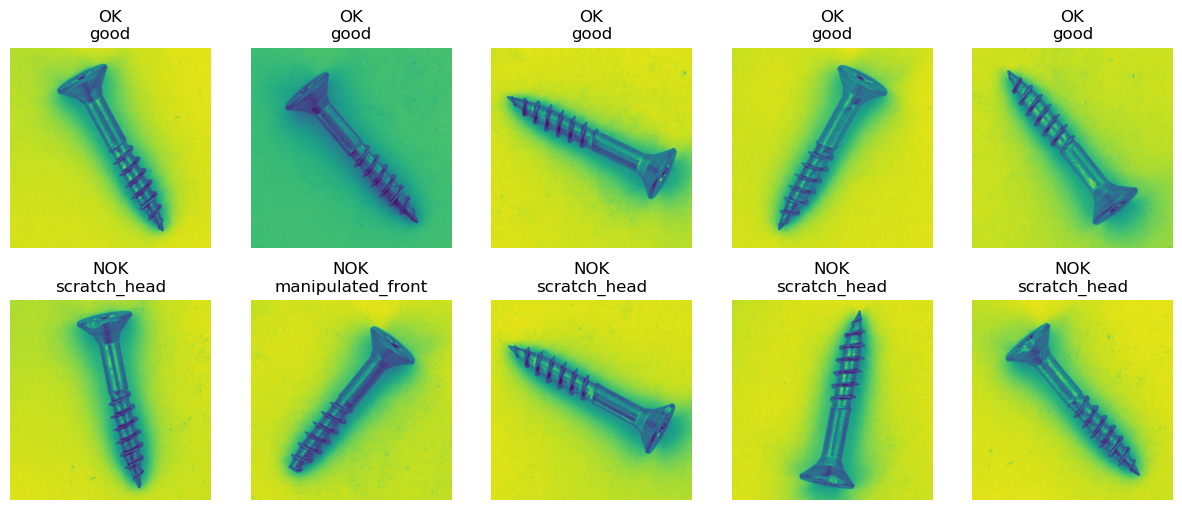

In [38]:
plt.subplots(nrows=2, ncols=5, figsize=(15, 6))

for sample_idx, (_, sample_row) in enumerate(sample_rows.iterrows()):
    img = Image.open(sample_row['full_path'])
    plt.subplot(2, 5, sample_idx + 1)
    plt.imshow(img)
    plt.title(f"{sample_row['category']}\n{sample_row['defect_type']}")
    plt.axis('off')

In [39]:
train_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((224, 224)),
    torchvision.transforms.RandomHorizontalFlip(p=0.5),
    torchvision.transforms.ColorJitter(brightness=0.1, contrast=0.2),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((224, 224)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [40]:
class ScrewDataset(torch.utils.data.Dataset):
    def __init__(self, manifest, images_dir, transform):
        self.manifest = manifest
        self.images_dir = images_dir
        self.transform = transform
        self.label_map = {'NOK': 1, 'OK': 0}


    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, idx):
        row = self.manifest.iloc[idx]

        img_path = Path(self.images_dir, row['new_filepath'])

        image = Image.open(img_path)
        image = image.convert('RGB')
        image = self.transform(image)

        label = self.label_map[row['category']]

        return image, label


        

In [41]:
train_dataset = ScrewDataset(train_manifest, TRAIN_DIR, train_transform)
val_dataset = ScrewDataset(val_manifest, VAL_DIR, eval_transform)
test_dataset = ScrewDataset(test_manifest, TEST_DIR, eval_transform)

In [42]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)


In [43]:
model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
model.fc = torch.nn.Linear(in_features=model.fc.in_features, out_features=2, bias=True)


In [44]:
model = model.to(device)

In [45]:
model.fc

Linear(in_features=512, out_features=2, bias=True)

In [46]:
def train_one_epoch(model, loader,criterion, optimizer, device):
    model.train()
    loss_sum = 0
    samples_count = 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * images.shape[0]
        samples_count += images.shape[0]
        
        

    return loss_sum/samples_count

In [ ]:
nok_weight = len(train_manifest)/(len(train_manifest[train_manifest['category']=='NOK'])*len(train_manifest['category'].value_counts()))
ok_weight = len(train_manifest)/(len(train_manifest[train_manifest['category']=='OK'])*len(train_manifest['category'].value_counts()))
weight_tensor = torch.tensor([ok_weight, nok_weight], dtype=torch.float32)

In [48]:
criterion = torch.nn.CrossEntropyLoss(weight=weight_tensor)
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-3)

In [49]:
loader_subset = torch.utils.data.Subset(train_dataset, range(32))
loader = torch.utils.data.DataLoader(loader_subset, batch_size=16, shuffle=False, num_workers=0)

In [50]:
test = train_one_epoch(model=model, loader=loader, criterion=criterion, optimizer=optimizer, device=device)
test

0.8523881733417511

In [51]:
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, samples_count = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            logity = model(images)
            loss = criterion(logity, labels)
            preds = logity.argmax(dim=1)
            correct += (preds == labels).sum().item()
            loss_sum += loss.item() * images.shape[0]
            samples_count += images.shape[0]
        val_loss = loss_sum / samples_count
        val_accuracy = correct/ samples_count


    return val_loss, val_accuracy



In [52]:
val_eval = evaluate(model=model, loader=val_loader, criterion=criterion, device=device)
val_eval

(0.8475037415822347, 0.5694444444444444)

In [53]:
NUM_EPOCHS = 30
PATIENCE = 5
best_val_loss = float("inf")
epochs_no_improve = 0
best_state = None
history = []

for epoch in range(1, NUM_EPOCHS+1):
    train_loss = train_one_epoch(model=model, loader=train_loader, criterion=criterion, optimizer=optimizer, device = device)
    val_loss, val_accuracy = evaluate(model=model, loader=val_loader, criterion=criterion, device=device)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,

    })

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_state = copy.deepcopy(model.state_dict())
    else:
        epochs_no_improve +=1
        if epochs_no_improve >= PATIENCE:
            break

model.load_state_dict(best_state)



<All keys matched successfully>

In [54]:
data =  pd.DataFrame(history)

In [55]:
data

,epoch,train_loss,val_loss,val_accuracy
0,1,0.982895,14.817929,0.250000
1,2,0.714583,0.673026,0.680556
2,3,0.678907,0.712720,0.277778
3,4,0.717069,0.629736,0.750000
4,5,0.721825,0.640591,0.750000
5,6,0.714756,0.615656,0.694444
6,7,0.740499,1.060010,0.750000
7,8,0.699995,0.647623,0.694444
8,9,0.704068,0.639841,0.736111
9,10,0.695106,0.642022,0.680556


In [56]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images).argmax(dim=1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=["OK", "NOK"]))

[[33 21]
 [ 1 17]]
              precision    recall  f1-score   support

          OK       0.97      0.61      0.75        54
         NOK       0.45      0.94      0.61        18

    accuracy                           0.69        72
   macro avg       0.71      0.78      0.68        72
weighted avg       0.84      0.69      0.71        72



In [57]:
torch.save(best_state, r'C:\Users\maciej.klimczak\maciej_klimczak\studia\inzynierka\models\resnet18_baseline\best.pth')

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd S

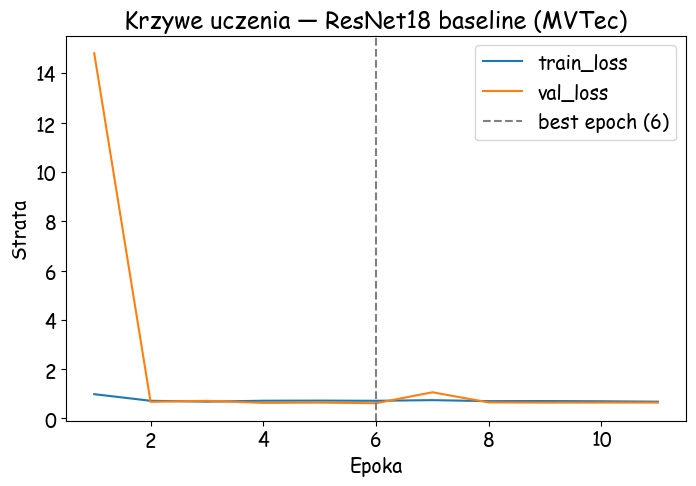

In [62]:
df = pd.DataFrame(history)
best_epoch = df.loc[df['val_loss'].idxmin(), 'epoch']

plt.figure(figsize=(8, 5))
plt.plot(df['epoch'], df['train_loss'], label='train_loss')
plt.plot(df['epoch'], df['val_loss'], label='val_loss')
plt.axvline(best_epoch, color='gray', linestyle='--', label=f'best epoch ({best_epoch})')
plt.xlabel('Epoka')
plt.ylabel('Strata')
plt.title('Krzywe uczenia — ResNet18 baseline (MVTec)')
plt.legend()
plt.show()